In [1]:
import pandas as pd

# load data
df_ct = pd.read_csv("../tmp/category_tree.csv")

In [2]:
# formato
print(f"formato {df_ct.shape}")
print(f"linhas {df_ct.shape[0]} | colunas {df_ct.shape[1]}")
print()

# head
print("head")
print(df_ct.head())
print()

# tail
print("tail")
print(df_ct.tail())
print()

# types
print("types")
print(df_ct.dtypes)
print()

# describe df_ev
df_ct.describe()

formato (1669, 2)
linhas 1669 | colunas 2

head
   categoryid  parentid
0        1016     213.0
1         809     169.0
2         570       9.0
3        1691     885.0
4         536    1691.0

tail
      categoryid  parentid
1664          49    1125.0
1665        1112     630.0
1666        1336     745.0
1667         689     207.0
1668         761     395.0

types
categoryid      int64
parentid      float64
dtype: object



,categoryid,parentid
count,1669.000000,1644.000000
mean,849.285201,847.571168
std,490.195116,505.058485
min,0.000000,8.000000
25%,427.000000,381.000000
50%,848.000000,866.000000
75%,1273.000000,1291.000000
max,1698.000000,1698.000000


In [3]:
# Separar colunas por tipo
colunas_numericas = df_ct.select_dtypes(
    exclude=["object", "category", "string", "datetime64"]
).columns.tolist()
colunas_categoricas = df_ct.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
colunas_data = df_ct.select_dtypes(include=["datetime64"]).columns.tolist()

print(f"Numéricas ({len(colunas_numericas)}):", colunas_numericas)
print(f"Categóricas ({len(colunas_categoricas)}):", colunas_categoricas)
print(f"Datas ({len(colunas_data)}):", colunas_data)

Numéricas (2): ['categoryid', 'parentid']
Categóricas (0): []
Datas (0): []


In [4]:
print("Quantidade de valor nulos por coluna")
print(df_ct.isnull().sum())
print()

print("Porcentagem de nulos")
print((df_ct.isnull().sum() / len(df_ct) * 100).round(2))
print()

print("Total duplicadas")
print(df_ct.duplicated().sum())
print()

Quantidade de valor nulos por coluna
categoryid     0
parentid      25
dtype: int64

Porcentagem de nulos
categoryid    0.0
parentid      1.5
dtype: float64

Total duplicadas
0



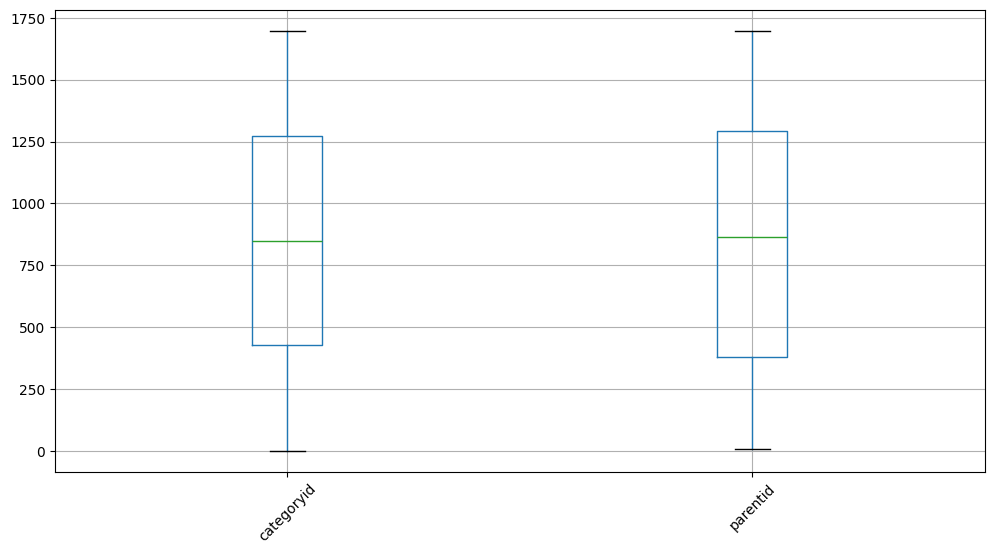

categoryid: 0 outliers
parentid: 0 outliers


In [5]:
import matplotlib.pyplot as plt

# Visualização rápida
df_ct[colunas_numericas].boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

# Método IQR
for col in colunas_numericas:
    Q1 = df_ct[col].quantile(0.25)
    Q3 = df_ct[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_ct[col] < Q1 - 1.5 * IQR) | (df_ct[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {outliers} outliers")

In [6]:
print("Valores únicos e frequência")
# Ver valores únicos e frequência
for col in colunas_categoricas:
    print(f"\n{col}: {df_ct[col].nunique()} valores únicos")
    print(df_ct[col].value_counts().head(10))

Valores únicos e frequência


## Quantidades
- Views em grandes quantidades 2664312
- Add to cart em segundo lugar 69332
- Transações em terceiro 22457

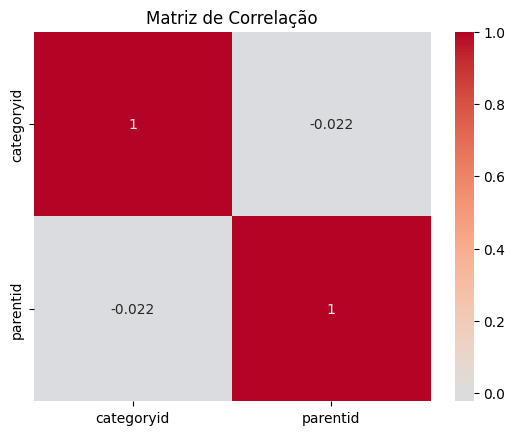

In [7]:
# Matriz de correlação
correlacao = df_ct[colunas_numericas].corr()

import seaborn as sns

# Visualizar
sns.heatmap(correlacao, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()

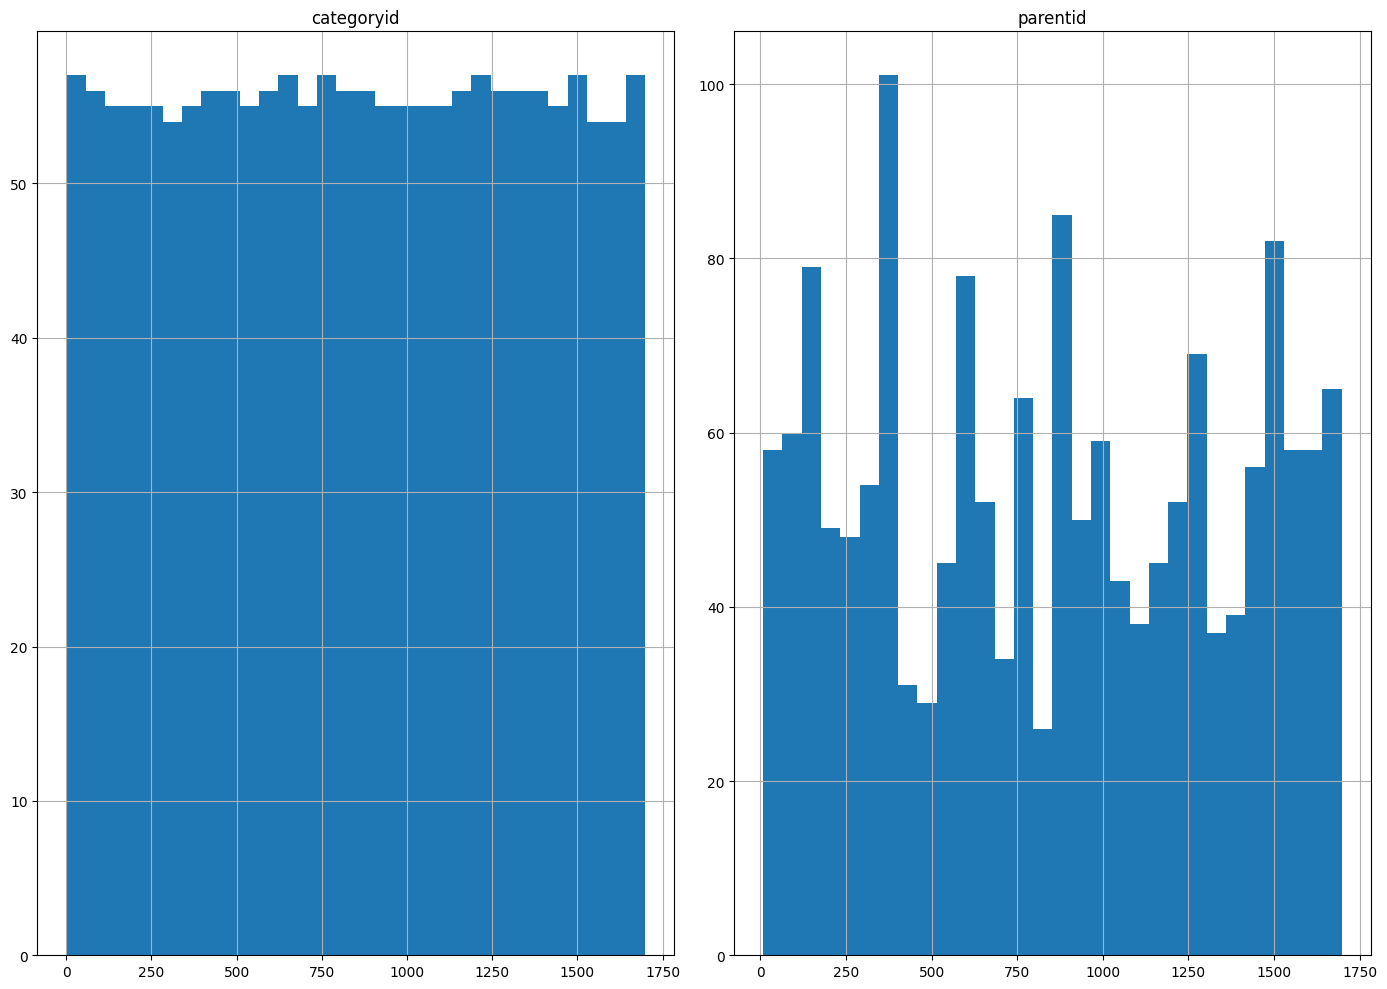

In [8]:
# Histograma para todas as numéricas
df_ct[colunas_numericas].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

# Countplot para categóricas principais
for col in colunas_categoricas[:5]:  # top 5
    plt.figure(figsize=(10, 4))
    sns.countplot(y=col, data=df_ct, order=df_ct[col].value_counts().index[:10])
    plt.title(f"Distribuição de {col}")
    plt.show()